In [60]:
import pandas as pd

df = pd.read_csv("bank_users.csv")

# Sort alphabetically by last_name, then first_name
df_sorted = df.sort_values(by=["last_name", "first_name"], ascending=True)

df_sorted.info()
df_sorted.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 63 to 82
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   first_name    200 non-null    object 
 1   last_name     200 non-null    object 
 2   email         192 non-null    object 
 3   bank_account  179 non-null    float64
 4   born_year     176 non-null    float64
 5   city          187 non-null    object 
dtypes: float64(2), object(4)
memory usage: 10.9+ KB


,first_name,last_name,email,bank_account,born_year,city
63,Wesley,Adamec,NaN,44.0,1987.0,Luocheng
173,Demetra,Alyokhin,dalyokhin4t@webnode.com,77.0,2020.0,Munjul
184,Claudette,Ancliffe,cancliffe54@printfriendly.com,73.0,2011.0,Al Ḩazm
116,Creight,Artis,cartis38@umn.edu,71.0,1985.0,Bratislava
39,Calv,Ary,cary13@nps.gov,56.0,2008.0,Pico da Pedra
12,Suzann,Ashling,sashlingc@cocolog-nifty.com,44.0,2020.0,Hongshunli
167,Calv,Auchinleck,cauchinleck4n@cbsnews.com,28.0,1963.0,Zhangyang
44,Roarke,Ayton,rayton18@freewebs.com,94.0,1954.0,Sagopshi
170,Arabela,Baile,abaile4q@marketwatch.com,15.0,2016.0,Verba
17,Willi,Baldcock,wbaldcockh@sourceforge.net,NaN,1950.0,Suwaru


In [5]:
# Fill missing values with "no value"
df_clean = df.fillna("no value")

# Fix last names with spaces after apostrophes
# Example: "O' Dooley" -> "O'Dooley"
df_clean["last_name"] = df_clean["last_name"].str.replace(r"\'\s+", "'", regex=True)

In [6]:
df_clean

,first_name,last_name,email,bank_account,born_year,city
0,Shawn,Gotts,sgotts0@newsvine.com,58.0,no value,Jinchuan
1,Sergeant,Linsey,slinsey1@qq.com,70.0,2007.0,Tāngāil
2,Ambrosio,Gorton,agorton2@google.es,48.0,2000.0,Zhushan Chengguanzhen
3,Gram,Steanyng,gsteanyng3@google.fr,92.0,1970.0,Hongxing
4,Britt,Cockaday,bcockaday4@t.co,78.0,1985.0,Nangabulik
...,...,...,...,...,...,...
195,Franz,Oppy,foppy5f@shutterfly.com,90.0,2020.0,Bílina Kyselka
196,Adolphus,Labbati,alabbati5g@yellowbook.com,56.0,1984.0,Berlin
197,Aurelea,Cordery,acordery5h@furl.net,no value,1992.0,Veshnyaki
198,Armstrong,Laughren,alaughren5i@yahoo.co.jp,87.0,1983.0,Detik Satu


In [7]:
# Sort alphabetically by last_name, then first_name
df_clean = df_clean.sort_values(by=["last_name", "first_name"])

df_clean.head(20)

,first_name,last_name,email,bank_account,born_year,city
63,Wesley,Adamec,no value,44.0,1987.0,Luocheng
173,Demetra,Alyokhin,dalyokhin4t@webnode.com,77.0,2020.0,Munjul
184,Claudette,Ancliffe,cancliffe54@printfriendly.com,73.0,2011.0,Al Ḩazm
116,Creight,Artis,cartis38@umn.edu,71.0,1985.0,Bratislava
39,Calv,Ary,cary13@nps.gov,56.0,2008.0,Pico da Pedra
12,Suzann,Ashling,sashlingc@cocolog-nifty.com,44.0,2020.0,Hongshunli
167,Calv,Auchinleck,cauchinleck4n@cbsnews.com,28.0,1963.0,Zhangyang
44,Roarke,Ayton,rayton18@freewebs.com,94.0,1954.0,Sagopshi
170,Arabela,Baile,abaile4q@marketwatch.com,15.0,2016.0,Verba
17,Willi,Baldcock,wbaldcockh@sourceforge.net,no value,1950.0,Suwaru


In [61]:
# Fix last names like "O' Dooley"
df_clean["last_name"] = df_clean["last_name"].str.replace(r"\'\s+", "'", regex=True)

# Convert born_year to numeric, invalid -> NaN
df_clean["born_year"] = pd.to_numeric(df_clean["born_year"], errors="coerce")

# Compute age (assuming current year = 2026)
df_clean["age"] = 2026 - df_clean["born_year"]

# Convert bank_account to numeric
df_clean["bank_account"] = pd.to_numeric(df_clean["bank_account"], errors="coerce")

# Drop rows where age or bank_account is missing
df_valid = df_clean.dropna(subset=["age", "bank_account"])

In [64]:
df_valid

,first_name,last_name,email,bank_account,born_year,city,age,age_group
63,Wesley,Adamec,no value,44.0,1987.0,Luocheng,39.0,31–40
173,Demetra,Alyokhin,dalyokhin4t@webnode.com,77.0,2020.0,Munjul,6.0,0–20
184,Claudette,Ancliffe,cancliffe54@printfriendly.com,73.0,2011.0,Al Ḩazm,15.0,0–20
116,Creight,Artis,cartis38@umn.edu,71.0,1985.0,Bratislava,41.0,41–50
39,Calv,Ary,cary13@nps.gov,56.0,2008.0,Pico da Pedra,18.0,0–20
...,...,...,...,...,...,...,...,...
177,Georgeanne,Wickey,gwickey4x@tinypic.com,21.0,1966.0,Rāiwind,60.0,51–60
191,Cathrine,Wraith,cwraith5b@washington.edu,91.0,1993.0,Jinxiu,33.0,31–40
188,Deidre,Yglesia,dyglesia58@51.la,23.0,1960.0,Piekoszów,66.0,61–70
15,Lydia,Youngman,lyoungmanf@indiatimes.com,48.0,1966.0,Nevel’,60.0,51–60


In [10]:
# Create 6–7 Age Group
bins = [0, 20, 30, 40, 50, 60, 70, 200]
labels = ["0–20", "21–30", "31–40", "41–50", "51–60", "61–70", "71+"]

df_valid["age_group"] = pd.cut(df_valid["age"], bins=bins, labels=labels, right=True)


C:\Users\jarmi\AppData\Local\Temp\ipykernel_3580\1996488546.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["age_group"] = pd.cut(df_valid["age"], bins=bins, labels=labels, right=True)


In [11]:
df_valid

,first_name,last_name,email,bank_account,born_year,city,age,age_group
63,Wesley,Adamec,no value,44.0,1987.0,Luocheng,39.0,31–40
173,Demetra,Alyokhin,dalyokhin4t@webnode.com,77.0,2020.0,Munjul,6.0,0–20
184,Claudette,Ancliffe,cancliffe54@printfriendly.com,73.0,2011.0,Al Ḩazm,15.0,0–20
116,Creight,Artis,cartis38@umn.edu,71.0,1985.0,Bratislava,41.0,41–50
39,Calv,Ary,cary13@nps.gov,56.0,2008.0,Pico da Pedra,18.0,0–20
...,...,...,...,...,...,...,...,...
177,Georgeanne,Wickey,gwickey4x@tinypic.com,21.0,1966.0,Rāiwind,60.0,51–60
191,Cathrine,Wraith,cwraith5b@washington.edu,91.0,1993.0,Jinxiu,33.0,31–40
188,Deidre,Yglesia,dyglesia58@51.la,23.0,1960.0,Piekoszów,66.0,61–70
15,Lydia,Youngman,lyoungmanf@indiatimes.com,48.0,1966.0,Nevel’,60.0,51–60


C:\Users\jarmi\AppData\Local\Temp\ipykernel_3580\4096390249.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_valid.groupby("age_group")["bank_account"].sum()


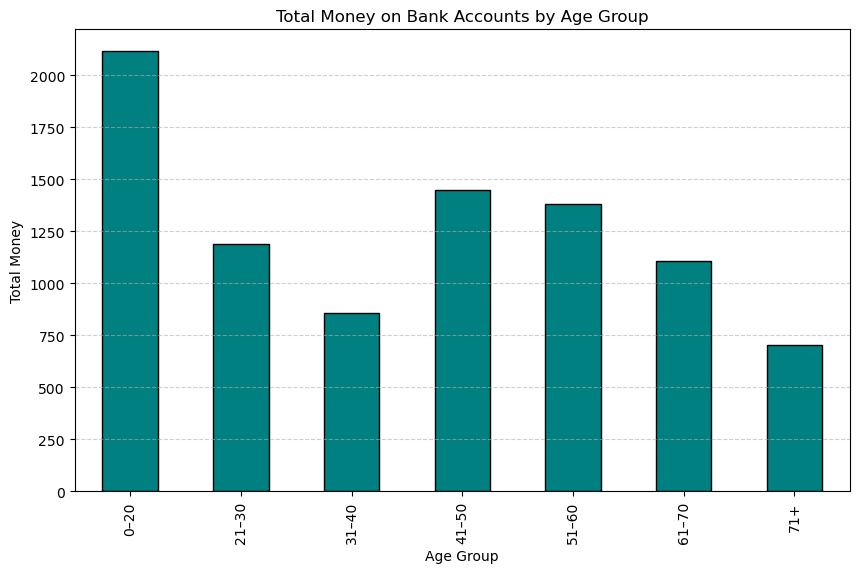

In [13]:
# Plot: Histogram of Money by Age Group
import matplotlib.pyplot as plt
import numpy as np
grouped = df_valid.groupby("age_group")["bank_account"].sum()

plt.figure(figsize=(10, 6))
grouped.plot(kind="bar", color="teal", edgecolor="black")

plt.title("Total Money on Bank Accounts by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Money")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


In [47]:
# Replace "no value" back to NaN for missing-value analysis
df_sorted["born_year"] = pd.to_numeric(df_sorted["born_year"])
df_sorted["age"] = 2026 - df_sorted["born_year"]
df_sorted["age_group"] = pd.cut(df_sorted["age"], bins=bins, labels=labels, right=True)
df_missing = df_sorted.replace("no value", np.nan)

missing_counts = (
    df_missing
    .groupby("age_group")[["email", "bank_account", "city"]]
    .apply(lambda x: x.isna().sum())
)
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 63 to 82
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   first_name    200 non-null    object  
 1   last_name     200 non-null    object  
 2   email         192 non-null    object  
 3   bank_account  179 non-null    float64 
 4   born_year     176 non-null    float64 
 5   city          187 non-null    object  
 6   age           176 non-null    float64 
 7   age_group     176 non-null    category
dtypes: category(1), float64(3), object(4)
memory usage: 13.0+ KB


C:\Users\jarmi\AppData\Local\Temp\ipykernel_3580\2242060133.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_group")[["email", "bank_account", "city"]]


<Figure size 1200x600 with 0 Axes>

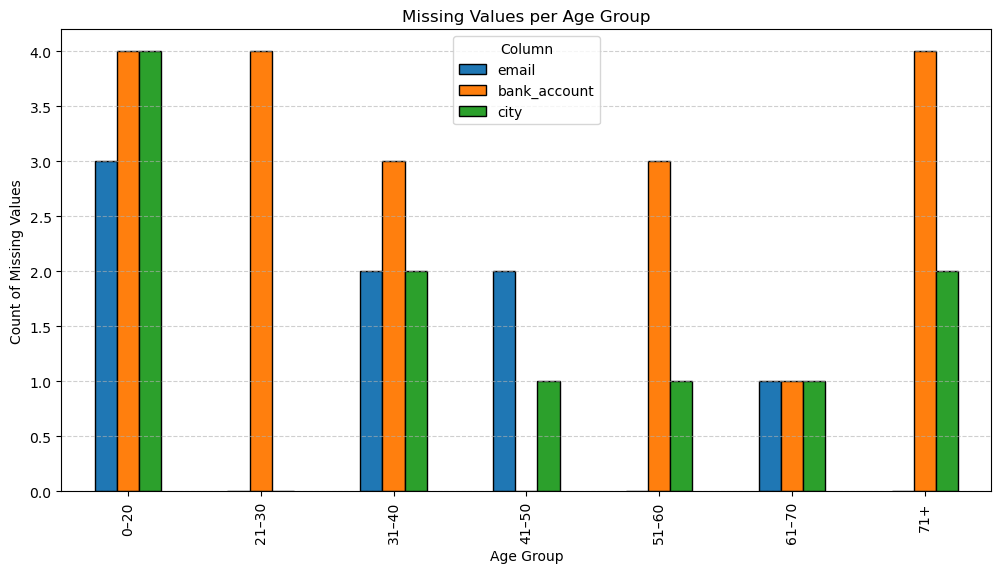

In [48]:
plt.figure(figsize=(12, 6))

missing_counts.plot(kind="bar", figsize=(12, 6), edgecolor="black")

plt.title("Missing Values per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count of Missing Values")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Column")

plt.show()

In [51]:
# ✔ Younger groups (0–20, 21–30)
# Many missing born_year and bank_account values.

# ✔ Middle-aged groups (31–50)
# More complete data, fewer missing values.

# ✔ Older groups (71+)
# Surprisingly many missing city values.